# 11 — Análise Temporal de Degradação do CA65926

**Motivação:** Sprint 2 destacou CA65926 (793-D 4S) como outlier extremo. Este notebook recorta sua história mensal para responder: **quando começa a degradação estrutural?** A figura resultante é um dos achados executivos mais impactantes do trabalho.

Pipeline: `uv run python src/sprint7_ca65926_temporal.py`.

In [1]:
import json
from pathlib import Path
import pandas as pd
from IPython.display import Image, display

ROOT = Path.cwd().parent
data = json.loads((ROOT / 'outputs' / 'gold' / 'ca65926_temporal.json').read_text())
fig_dir = ROOT / 'outputs' / 'figures'
print(f"TAG: {data['tag']} | Frota: {data['frota']}")
print(f"Fator de escalada interno: {data['escalation_factor']:.0f}× entre menor e maior mês")

TAG: CA65926 | Frota: 793-D 4S
Fator de escalada interno: 100× entre menor e maior mês


## 1. Estatística Mensal do CA65926

In [2]:
monthly = pd.DataFrame(data['monthly'])
display(monthly[['mes_str', 'n_eventos', 'n_dont_go', 'taxa_dg_pct', 'taxa_pre_dg_pct',
                  'criticos_30m_p95', 'aceleracao_med']].style.format({
    'taxa_dg_pct': '{:.3f}%', 'taxa_pre_dg_pct': '{:.2f}%',
    'criticos_30m_p95': '{:.1f}', 'aceleracao_med': '{:.3f}',
    'n_eventos': '{:,}', 'n_dont_go': '{:,}',
}).background_gradient(subset=['taxa_dg_pct'], cmap='Reds'))

,mes_str,n_eventos,n_dont_go,taxa_dg_pct,taxa_pre_dg_pct,criticos_30m_p95,aceleracao_med
0,2025-01,"14,380",31,0.216%,5.63%,3.0,0.000
1,2025-02,"14,561",56,0.385%,6.25%,1.0,0.000
2,2025-03,"17,387",438,2.519%,33.57%,1.0,0.000
3,2025-04,"13,117",34,0.259%,5.73%,1.0,0.000
4,2025-05,"15,979",66,0.413%,6.84%,1.0,0.000
5,2025-06,"20,796","4,487",21.576%,62.39%,31.0,0.872


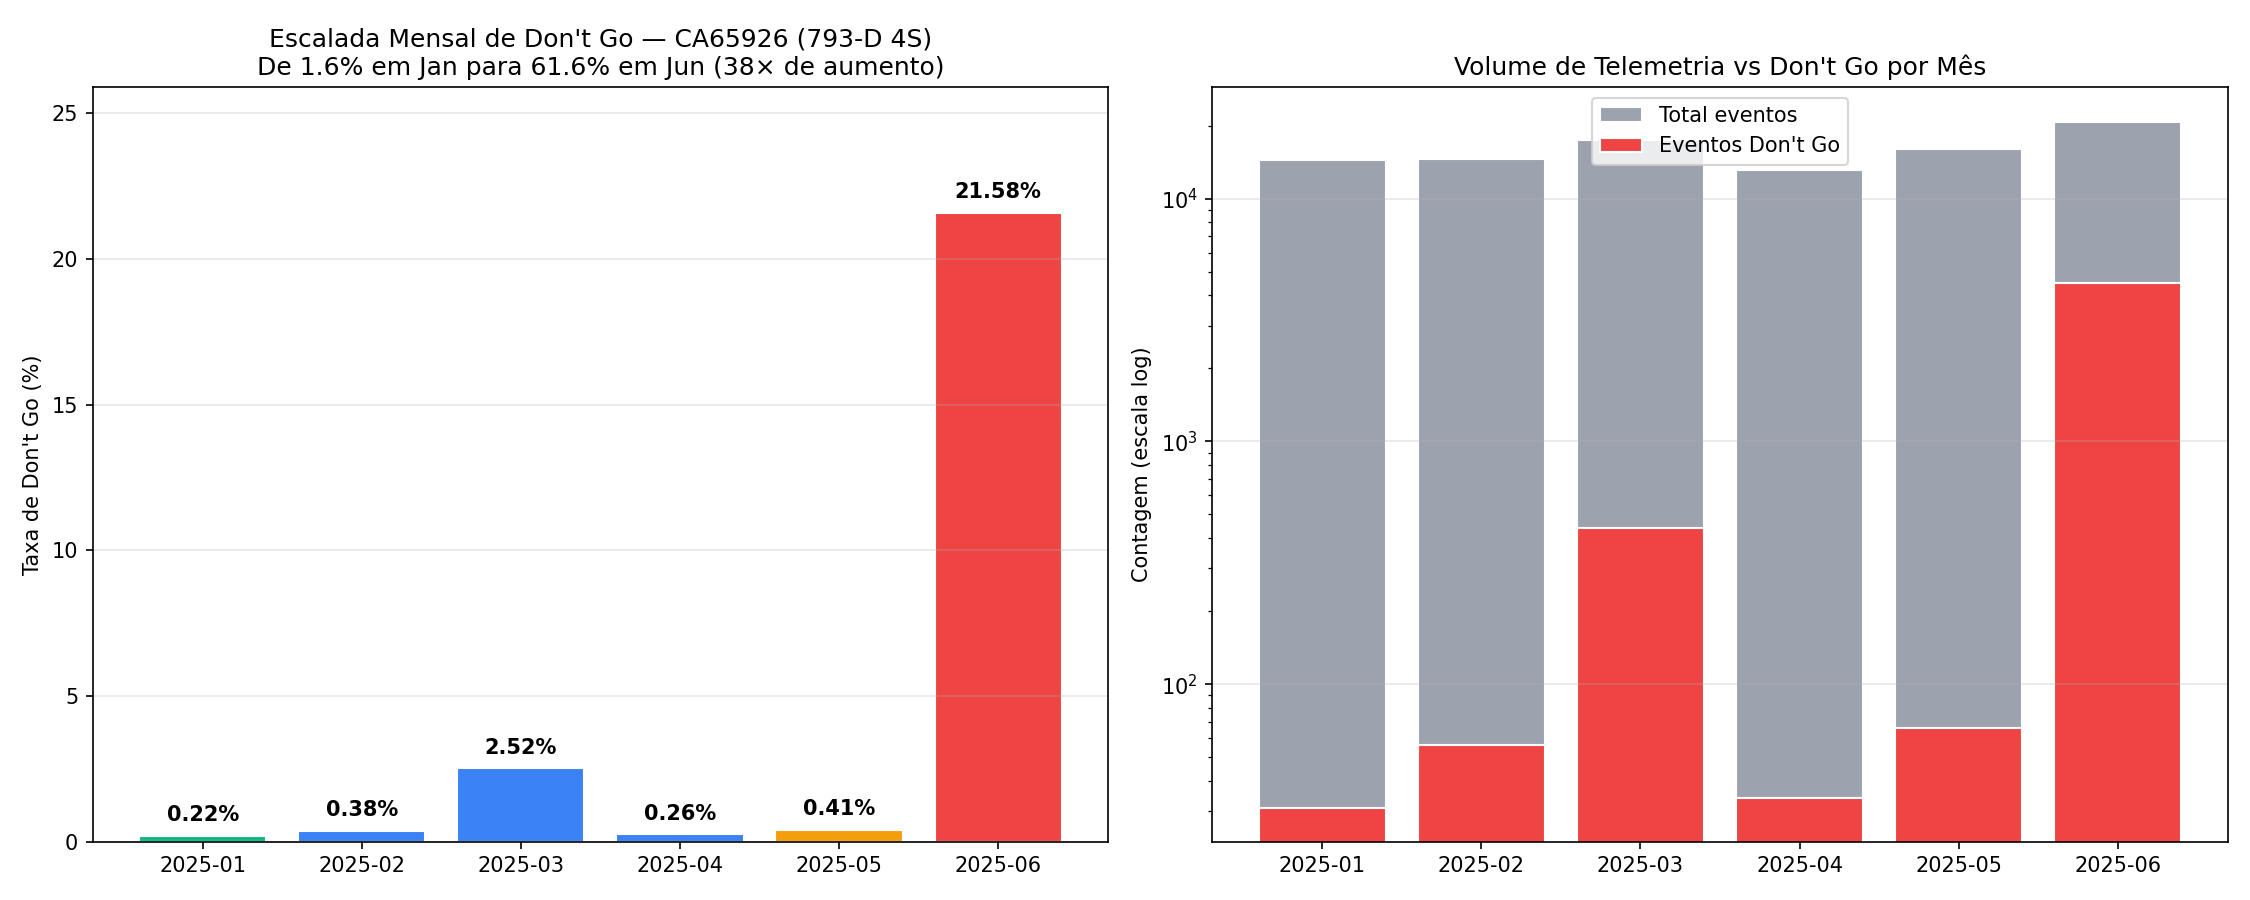

In [3]:
display(Image(filename=str(fig_dir / 'ca65926_monthly_escalation.png')))

## 2. Comparação com a Média da Frota 793-D 4S

A pergunta-chave: o CA65926 sempre foi o pior, ou a degradação é estrutural e recente?

In [4]:
comp = pd.DataFrame(data['comparison_with_fleet_4s'])
comp['razao'] = comp['taxa_dg_pct'] / comp['taxa_4s']
display(comp.style.format({
    'taxa_dg_pct': '{:.3f}%', 'taxa_4s': '{:.3f}%', 'razao': '{:.1f}×'
}).background_gradient(subset=['razao'], cmap='Reds'))

,mes_label,taxa_dg_pct,taxa_4s,razao
0,JAN,0.216%,0.592%,0.4×
1,FEB,0.385%,0.617%,0.6×
2,MAR,2.519%,0.297%,8.5×
3,ABR,0.259%,0.113%,2.3×
4,MAY,0.413%,0.146%,2.8×
5,JUN,21.576%,0.105%,205.1×


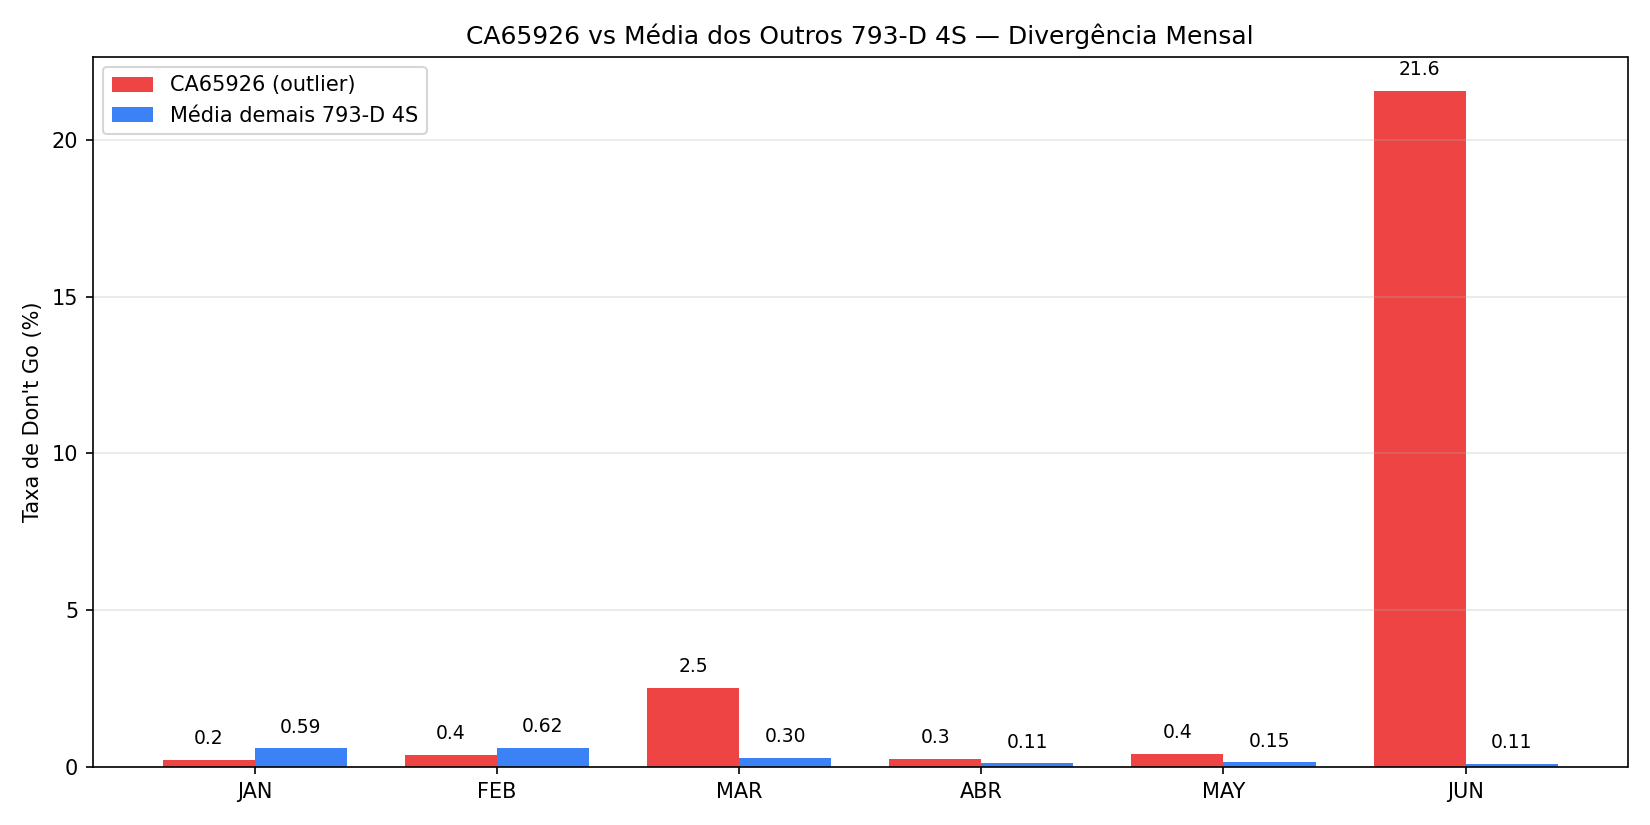

In [5]:
display(Image(filename=str(fig_dir / 'ca65926_vs_frota.png')))

### Cronologia do colapso

| Mês | Taxa CA65926 | Média 793-D 4S | Razão | Status |
|---|---|---|---|---|
| Janeiro | 0,22% | 0,59% | **menor que média** | Operação normal — abaixo do esperado |
| Fevereiro | 0,38% | 0,62% | abaixo da média | Operação normal |
| **Março** | **2,52%** | 0,30% | **8,5×** | **Primeiro surto** — desvio estrutural |
| Abril | 0,26% | 0,11% | 2,4× | Recuou mas se mantém acima da média |
| Maio | 0,41% | 0,15% | 2,7× | Tendência crescente |
| **Junho** | **21,58%** | 0,11% | **205×** | **Colapso operacional** |

**Inversão completa entre Jan e Jun:** em Janeiro, CA65926 estava ABAIXO da média da sua frota (0,22% vs 0,59%). Em Junho, está 205 vezes acima.

## 3. Série Temporal Diária

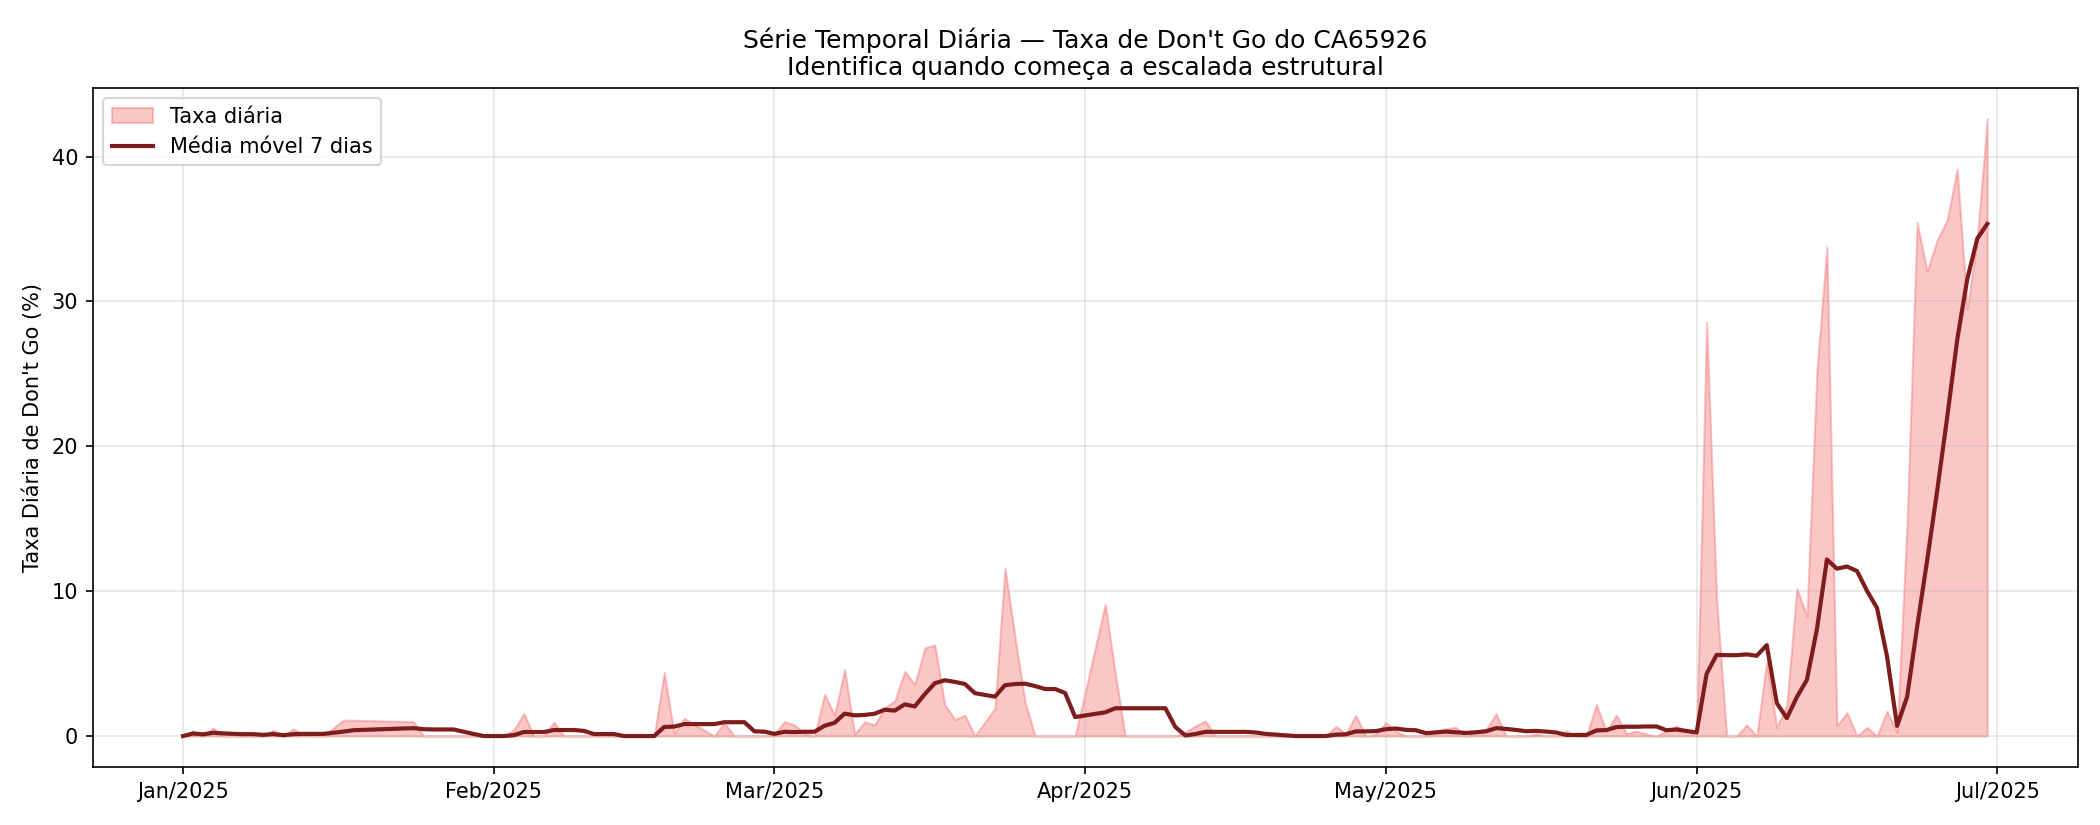

In [6]:
display(Image(filename=str(fig_dir / 'ca65926_daily_timeline.png')))

## 4. Interpretação Operacional

1. **CA65926 não nasceu problemático.** Em Jan-Fev/2025 estava abaixo da média da frota 793-D 4S. Isto refuta uma hipótese implícita de "equipamento ruim" e desloca o diagnóstico para **degradação estrutural recente**.
2. **Março foi um sinal de alerta antecipado.** O primeiro surto (2,52% vs 0,30% da frota — 8,5× a média) deveria ter motivado inspeção mais profunda. O recuo em Abril foi engano: a tendência se reverteu.
3. **Junho é colapso.** Taxa de DG 205× a média da frota não é variabilidade aleatória — é falha sistêmica. Substituição de componente principal, parada para revisão geral ou aposentadoria do equipamento são opções a considerar.
4. **Padrão de aceleração.** A mediana de `aceleracao_criticos` saltou para 0,87 em Junho, vs 0,00 nos meses anteriores. O critério mais ativo do modelo está pegando exatamente esta dinâmica.
5. **Valor preventivo de modelos preditivos.** Se o sistema preditivo tivesse sido aplicado em Março, o surto teria sido detectado precocemente e ações poderiam ter sido tomadas antes do colapso de Junho.

## 5. Recomendação Operacional Imediata

**O CA65926 deve ser retirado de operação para inspeção estrutural completa.** A escalada de 100× internamente (entre o melhor e o pior mês) e o pico de 205× a média da frota são incompatíveis com manutenção corretiva padrão. Recomenda-se:

- Inspeção completa de componentes críticos (transmissão, freios, sistema hidráulico).
- Revisão do histórico de manutenções entre Fev e Mar/2025 para identificar o evento que precedeu o primeiro surto.
- Análise comparativa de operadores designados antes/depois — se houver dados (atualmente ausentes do parquet).
- Decisão executiva: continuar reparando, ou aposentar e reduzir o ativo total da frota.